In [1]:
import numpy as np
from PIL import Image
from PIL import ImageDraw
from shapely import Point
from matplotlib import pyplot as plt
import cameratransform as ct

**Labelling Functions**

In [2]:
def interpret_labels(raw):
    """
    Converts raw labels in form
    
    [x1, y1, x2, y2, ... xn, yn, x1, y1]
    
    to a 2-Dimensional Numpy Array in form
    
    [[x1, y1], [x2, y2], ...]
    """
    return np.array([(raw[i], raw[i+1]) for i in range(0, len(raw), 2)])

def visualize_labels(image: Image, labels: np.array):
    """
    Draws the labels in form
    
    [x1, y1, x2, y2, ... xn, yn, x1, y1]
    
    to the image as a polygon.
    """
    if labels.shape[0] < 3 or labels.shape[1] != 2:
        raise ValueError("Labels must contain at least 3 points and shape (n,2).")

    base = image.convert("RGBA")

    # Transparent overlay
    overlay = Image.new("RGBA", base.size, (0,0,0,0))
    draw = ImageDraw.Draw(overlay)

    draw.polygon(
        labels.flatten().tolist(),
        outline=(255,0,0,255),
        fill=(255,0,0,60)  # faint red
    )

    result = Image.alpha_composite(base, overlay)

    display(result)

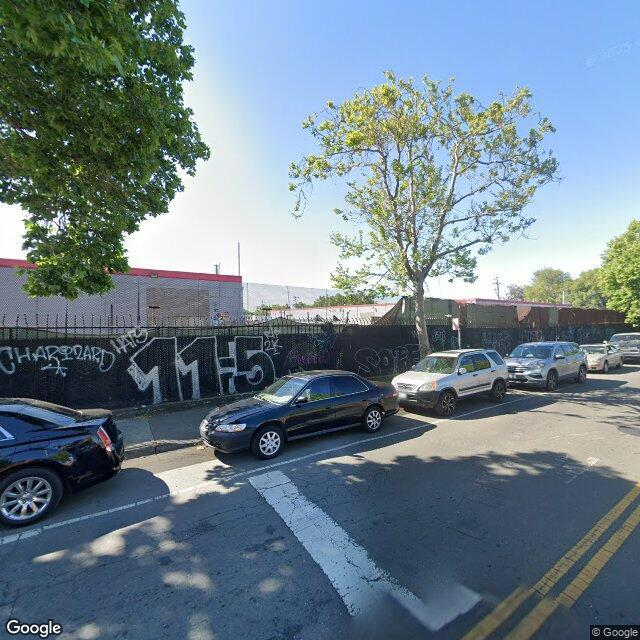

In [13]:
example_image = Image.open(f'example/example.png')
example_image_coords = Point(37.733812, -122.177631)
lat0, lon0 = 37.733812, -122.177631
display(example_image)

In [4]:
example_labels = interpret_labels([0, 540, 639, 365, 639, 345, 0, 490])
print(example_labels)

[[  0 540]
 [640 365]
 [640 345]
 [  0 490]]


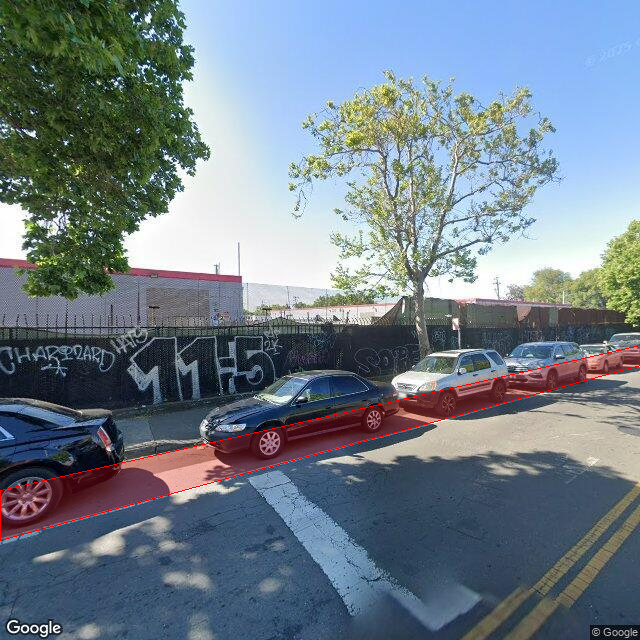

In [5]:
visualize_labels(example_image, example_labels)

In [6]:
# builds the camera

so = ct.SpatialOrientation(
    elevation_m=2.5,
    heading_deg=171,
    tilt_deg=90
)

proj = ct.RectilinearProjection(
    view_x_deg=60,
    image=np.asarray(example_image)
)

camera = ct.Camera(proj, so)
camera.setGPSpos(lat0, lon0)

In [16]:
def img_to_gps(image_coords):
    return [camera.gpsFromImage(coord)[0:2] for coord in image_coords]

In [17]:
gps_coords = img_to_gps(example_labels)
gps_coords

[array([  37.73376117, -122.17757895]),
 array([  37.73351348, -122.17777589]),
 array([  37.73327466, -122.17789181]),
 array([  37.73374622, -122.17756365])]

In [19]:
import folium

# Create map centered at the camera
m = folium.Map(location=[lat0, lon0], zoom_start=18)

# Add polygon
folium.Polygon(
    locations=gps_coords,
    color='red',
    weight=3,
    fill=False
).add_to(m)

# Optional: add markers at vertices
for lat, lon in gps_coords:
    folium.CircleMarker(location=(lat, lon), radius=3, color='blue').add_to(m)
    
folium.Marker(
    location=[lat0,lon0],
    popup=f"Camera Position"
).add_to(m)

# Display map
m